In [29]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("C:/Users/GAYATHARI/Downloads/cleaned_superstore_dataset.xls")

In [30]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Day
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,8
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,8
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,12
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,11
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,11


In [31]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Year', 'Month', 'Day']


In [32]:
total_sales = df['Sales'].sum()

total_products = df['Product ID'].nunique()

total_orders = df['Order ID'].nunique()

avg_order_value = total_sales / total_orders

print("Total Sales:", total_sales)
print("Total Products:", total_products)
print("Total Orders:", total_orders)
print("Average Order Value:", avg_order_value)

Total Sales: 2261536.7827
Total Products: 1861
Total Orders: 4922
Average Order Value: 459.4751691791954


In [33]:
category_analysis = df.groupby('Category')['Sales'].sum()

print(category_analysis)

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


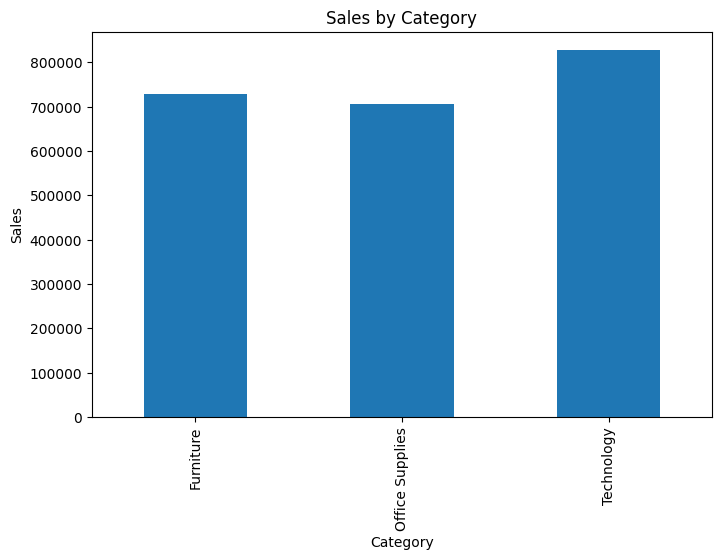

In [34]:
category_analysis.plot(kind='bar', figsize=(8,5))

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

In [35]:
region_analysis = df.groupby('Region')['Sales'].sum()

print(region_analysis)

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


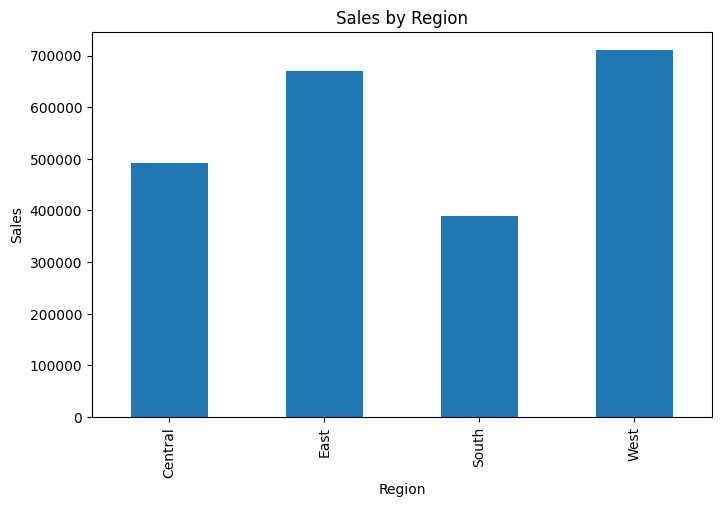

In [36]:
region_analysis.plot(kind='bar', figsize=(8,5))

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

In [37]:
top_customers = df.groupby('Customer Name')['Sales'].sum() \
                  .sort_values(ascending=False) \
                  .head(10)

print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


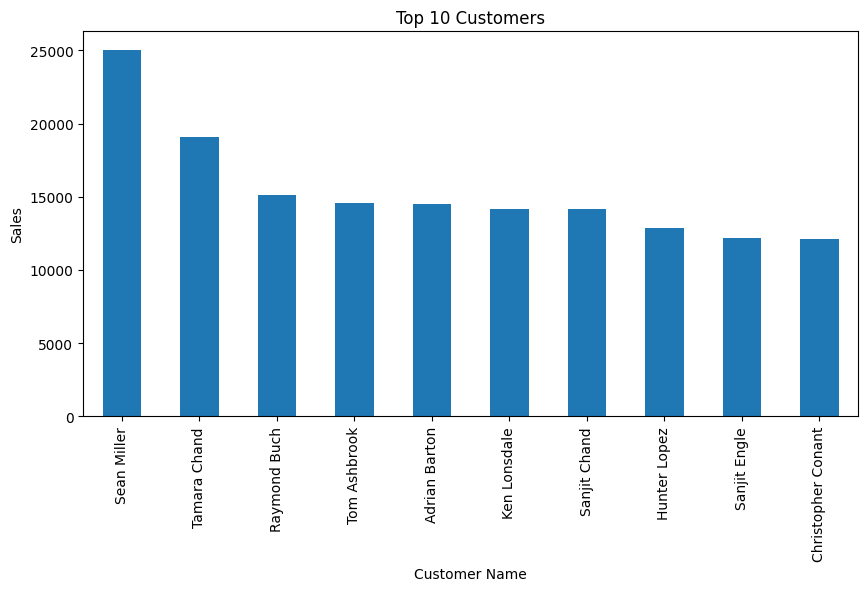

In [38]:
top_customers.plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Customers")
plt.xlabel("Customer Name")
plt.ylabel("Sales")

plt.show()

In [39]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Month_Year'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month_Year')['Sales'].sum()

print(monthly_sales)

Month_Year
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     75249.3995
2016-12     74543.6012
2017-01     18542.4910
2017-02     22978.8150
2017-03     51165.0590
2017-04     38679.7670
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59583.0330
2017-11     79066.4958
2017-12     95739.1210
2018-01     43476.4740
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07     44825.1040


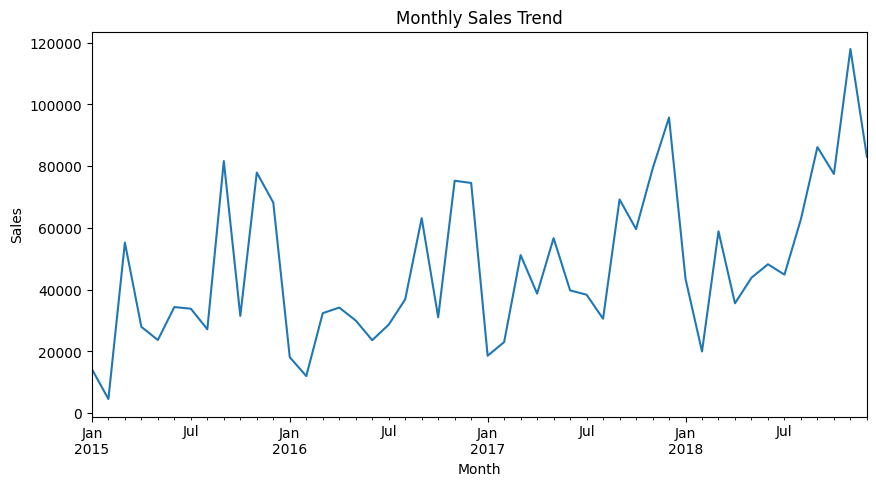

In [41]:
monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [42]:
segment_analysis = df.groupby('Segment')['Sales'].sum()

print(segment_analysis)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


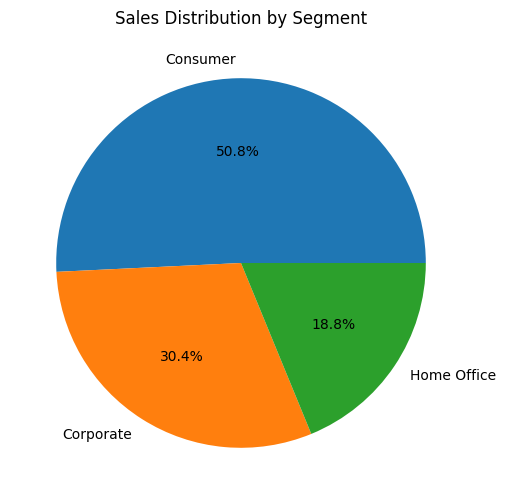

In [43]:
segment_analysis.plot(kind='pie',
                      autopct='%1.1f%%',
                      figsize=(6,6))

plt.title("Sales Distribution by Segment")
plt.ylabel('')

plt.show()

In [44]:
top_products = df.groupby('Product Name')['Sales'].sum() \
                 .sort_values(ascending=False) \
                 .head(10)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


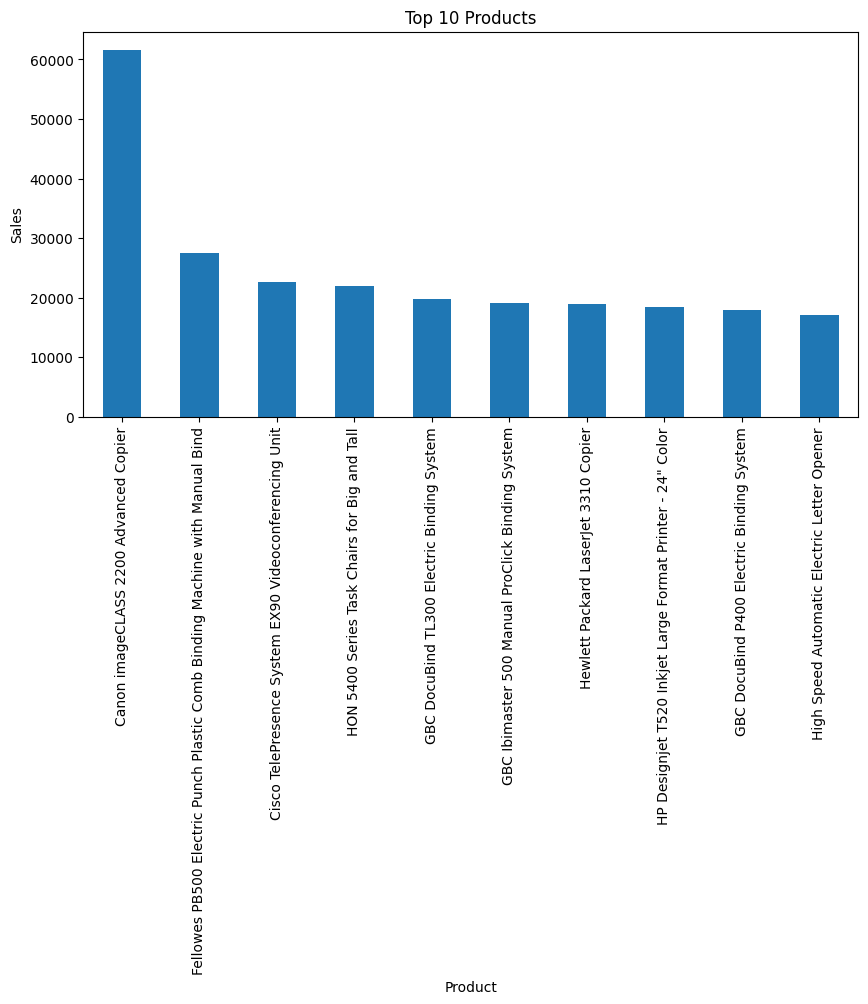

In [45]:
top_products.plot(kind='bar', figsize=(10,5))

plt.title("Top 10 Products")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.show()

In [46]:
top_states = df.groupby('State')['Sales'].sum() \
               .sort_values(ascending=False) \
               .head(10)

print(top_states)

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64


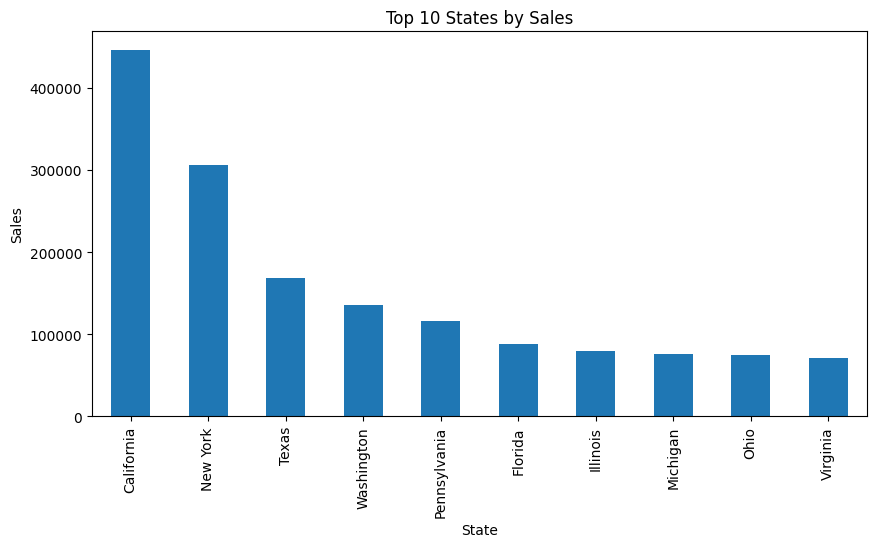

In [47]:
top_states.plot(kind='bar', figsize=(10,5))

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")

plt.show()